# Simulation Auditability Evaluation

Runs the three audit tests (calibration, discriminatory power, stability) across every DGP seed

In [1]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import plotting_config 
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import kendalltau, norm
from minou_colours import MINOU_COLOURS

STUDY_ROOT = Path("../..").resolve()
sys.path.insert(0, str(STUDY_ROOT))

import configs
from common.decision import newey_west_lrv
from common.io_utils import StudyPaths

AUDIT_SEEDS = [42, 43, 44, 45, 46]

BASELINE_LAMBDA = 10
BASELINE_T = 500
BASELINE_RHO = 0.03

SPLIT_NAME = "main"

SIG_LEVEL = 0.05   # significance level for the calibration and discrimination tests
NW_LAGS = 4        # Newey-West HAC lag count for the calibration test

pd.set_option("display.float_format", "{:.6f}".format)

paths = StudyPaths(study_root=STUDY_ROOT)

FIGURES_DIR = STUDY_ROOT / "figures" / "03_auditability"

DISPLAY_NAMES = {"linear": "PTO Linear", "mlp": "PTO MLP", "dfl_linear": "DFL Linear", "dfl_mlp": "DFL MLP",
                  "blackbox_linear": "BB Linear", "blackbox_mlp": "BB MLP", "persistence": "Persistence"}

COMBOS = [
    ("linear", "pto", "linear"), ("mlp", "pto", "mlp"), ("persistence", "pto", "persistence"),
    ("dfl_linear", "dfl", "linear"), ("dfl_mlp", "dfl", "mlp"),
    ("blackbox_linear", "blackbox", "linear"), ("blackbox_mlp", "blackbox", "mlp"),
]

PD_MODELS = [
    model_name for model_name, _, _ in COMBOS
    if model_name not in {"blackbox_linear", "blackbox_mlp"}
]

MODEL_COLOURS = {"linear": MINOU_COLOURS["gold"], "mlp": MINOU_COLOURS["teal"], "dfl_linear": MINOU_COLOURS["purple"],
          "dfl_mlp": MINOU_COLOURS["sage"], "blackbox_linear": MINOU_COLOURS["coral"], "blackbox_mlp": MINOU_COLOURS["navy"],
          "persistence": MINOU_COLOURS["grey"]}

## Helper functions

In [2]:
def mean_bias_test(pd_hat, target, nw_lags=NW_LAGS):
    """Two-sided HAC test of bias"""
    d = np.asarray(pd_hat, dtype=float) - np.asarray(target, dtype=float)
    n = len(d)
    bias = float(np.mean(d))
    mean_target = float(np.mean(np.asarray(target, dtype=float)))
    relative_bias = bias / mean_target if abs(mean_target) > 1e-12 else float("nan")
    sign = "positive" if bias > 0 else ("negative" if bias < 0 else "zero")

    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return dict(bias=bias, relative_bias=relative_bias, sign=sign,
                    hac_se=float("nan"), z_stat=float("nan"), p_value=float("nan"), n=n)
    hac_se = float(np.sqrt(lrv))
    z_stat = bias / hac_se
    p_value = 2.0 * norm.sf(abs(z_stat))
    return dict(bias=bias, relative_bias=relative_bias, sign=sign,
                hac_se=hac_se, z_stat=float(z_stat), p_value=float(p_value), n=n)


def load_audit_long(seed):
    """Concatenate per-(model_family, architecture) timeseries CSVs for one DGP seed."""
    frames, missing = [], []
    for model_name, family, arch in COMBOS:
        csv_path = paths.timeseries_csv(family, arch, seed, BASELINE_LAMBDA,
                                         BASELINE_T, BASELINE_RHO, SPLIT_NAME)
        if not csv_path.exists():
            missing.append((model_name, csv_path))
            continue
        frames.append(pd.read_csv(csv_path, parse_dates=["date"]))
    if not frames:
        return None, missing
    return pd.concat(frames, ignore_index=True), missing


## Calibration and discriminatory power test functions

In [3]:
def build_calibration_table(audit_long, pd_models, target_col):
    rows = []
    for model_name in pd_models:
        g = audit_long[audit_long["model"] == model_name].sort_values("date")
        # Run mean bias test for each model
        res = mean_bias_test(g["pd_q_hat"], g[target_col])
        rows.append({
            "model": model_name, "n": res["n"], "bias": res["bias"], "bias_bp": res["bias"] * 1e4,
            "sign": res["sign"], "relative_bias_pct": res["relative_bias"] * 100,
            "hac_se": res["hac_se"], "z_stat": res["z_stat"], "p_value": res["p_value"],
            "result": "significant bias" if res["p_value"] < SIG_LEVEL else "no significant bias",
        })
    return pd.DataFrame(rows).set_index("model").loc[pd_models]


def build_discrimination_table(audit_long, pd_models):
    rows = []
    for model_name in pd_models:
        g = audit_long[audit_long["model"] == model_name].sort_values("date")
        # Run Kendall's Tau test for each model
        tau, p_value = kendalltau(g["pd_q_hat"], g["pd_q_true"])
        passes = (tau > 0) and (p_value < SIG_LEVEL)
        rows.append({
            "model": model_name, "n": len(g), "tau": float(tau), "p_value": float(p_value),
            "result": "significant positive discrimination" if passes else "no significant positive discrimination",
        })
    return pd.DataFrame(rows).set_index("model").loc[pd_models]

## Stability ratios

In [4]:
def load_reference_predictions(family, kind, seed):
    """Per-refit predictions at a fixed reference input set, for a given DGP seed"""
    if family == "pto" and kind == "linear":
        path = paths.pto_stability_linear_csv(seed, BASELINE_LAMBDA, BASELINE_T,
                                              BASELINE_RHO, SPLIT_NAME)
    elif family == "pto" and kind == "mlp":
        path = paths.pto_stability_mlp_csv(seed, BASELINE_LAMBDA, BASELINE_T,
                                            BASELINE_RHO, SPLIT_NAME)
    elif kind == "linear":
        path = paths.stability_linear_csv(family, seed, BASELINE_LAMBDA,
                                          BASELINE_T, BASELINE_RHO, SPLIT_NAME)
    else:
        path = paths.stability_mlp_csv(family, seed, BASELINE_LAMBDA,
                                       BASELINE_T, BASELINE_RHO, SPLIT_NAME)
    if not path.exists():
        return None
    return pd.read_csv(path)


def _sort_by_refit(df):
    """Sort refit steps incase they are out of order (should be added in chronological order)."""
    return df.sort_values("test_date").reset_index(drop=True)


def _reference_row_mask(df):
    """Select latest refit as full-sample reference"""
    mask = pd.Series(False, index=df.index)
    mask.iloc[-1] = True
    return mask


def dispersion_full_sample(df, metric):
    """D_refit against full-sample ref."""

    cols = [c for c in df.columns if re.match(rf"^ref\d+_{re.escape(metric)}_mean$", c)] # mean across seeds
    if not cols or len(df) < 2:
        return np.nan, 0
    df = _sort_by_refit(df)

    # Creates mask of reference point (last refit)
    ref_mask = _reference_row_mask(df)

    # Get reference prediction
    reference = df.loc[ref_mask, cols].iloc[0].to_numpy(dtype=float)
    # Get all other refit predcitions
    refits = df.loc[~ref_mask, cols].to_numpy(dtype=float)
  
    return float(np.sqrt(np.mean((refits - reference) ** 2))), len(refits)


def dispersion_successive(df, metric):
    """D_refit between pairs of successive refits."""

    cols = [c for c in df.columns if re.match(rf"^ref\d+_{re.escape(metric)}_mean$", c)]
    if not cols or len(df) < 3:
        return np.nan, 0
    

    values = _sort_by_refit(df)[cols].to_numpy(float)


    return float(np.sqrt(np.mean(np.diff(values, axis=0) ** 2))), len(values) - 1

def dispersion_seed(df, metric, seeds):
    """Dispersion across MLP training seeds over all refits."""
    # Extract predictions from relevant reference columns
    seed_cols = [c for c in df.columns if c.startswith("ref") and f"_{metric}_seed" in c]
    if not seed_cols:
        return np.nan

    df = _sort_by_refit(df)

    # Get each reference point id
    point_ids = sorted({c.split("_")[0][3:] for c in seed_cols})

    sq_devs = []

    for _, row in df.iterrows():
        for j in point_ids:
            cols = [f"ref{j}_{metric}_seed{int(s)}" for s in seeds]
            if all(c in df.columns for c in cols):
                v = row[cols].to_numpy(dtype=float)
                if not np.isnan(v).any():
                    sq_devs.append((v - v.mean()) ** 2)
                    
    # Pool across all ref point/refit/seeds 
    return (float(np.sqrt(np.mean(np.concatenate(sq_devs)))) if sq_devs else np.nan)

def build_stability_table(audit_long, pd_models, seed):
    stability_models = [t for t in COMBOS if t[0] in audit_long["model"].unique() and t[0] != "persistence"]
    stability_rows = []
    n_reference_points_seen = set()

    for model_name, family, kind in stability_models:
        g = audit_long[audit_long["model"] == model_name].sort_values("date")
        df = load_reference_predictions(family, kind, seed=seed)
        row = {"model": model_name}
        if df is None:
            stability_rows.append(row)
            continue

        if model_name in pd_models:
            rmse_pd_realised = float(np.sqrt(np.mean((g["pd_q_hat"] - g["pd_q_realised"]) ** 2)))
            d_pd_full, n_full = dispersion_full_sample(df, "pd_q_hat")
            d_pd_succ, n_succ = dispersion_successive(df, "pd_q_hat")
            d_pd_seed = dispersion_seed(df, "pd_q_hat", configs.MLP_ENSEMBLE_SEEDS)

            n_reference_points_seen.add(sum(1 for c in df.columns if re.match(r"^ref\d+_pd_q_hat_mean$", c)))
            row.update({
                "RMSE_PD_realised": rmse_pd_realised,
                "D_PD_full": d_pd_full, "n_refits_PD": n_full,
                "D_PD_successive": d_pd_succ, "D_seed_PD": d_pd_seed,
                "D_PD_full_over_RMSE_realised": d_pd_full / rmse_pd_realised if rmse_pd_realised else np.nan,
                "D_PD_full_over_D_seed": d_pd_full / d_pd_seed if d_pd_seed else np.nan,
                "D_PD_successive_over_RMSE_realised": d_pd_succ / rmse_pd_realised if rmse_pd_realised else np.nan,
                "D_PD_successive_over_D_seed": d_pd_succ / d_pd_seed if d_pd_seed else np.nan,
            })
        else:
            row.update({k: np.nan for k in [
                "RMSE_PD_realised", "D_PD_full", "D_PD_successive", "D_seed_PD",
                "D_PD_full_over_RMSE_realised", "D_PD_full_over_D_seed",
                "D_PD_successive_over_RMSE_realised",
                "D_PD_successive_over_D_seed"]})
            row["n_refits_PD"] = 0

        rmse_alpha = float(np.sqrt(np.mean((g["alpha_hat"] - g["alpha_oracle"]) ** 2)))
        d_alpha_full, n_full_a = dispersion_full_sample(df, "alpha_hat")
        d_alpha_succ, n_succ_a = dispersion_successive(df, "alpha_hat")
        d_alpha_seed = dispersion_seed(df,  "alpha_hat", configs.MLP_ENSEMBLE_SEEDS)

        n_reference_points_seen.add(sum(1 for c in df.columns if re.match(r"^ref\d+_alpha_hat_mean$", c)))
        row.update({
            "RMSE_alpha": rmse_alpha, "D_alpha_full": d_alpha_full, "n_refits_alpha": n_full_a,
            "D_alpha_successive": d_alpha_succ, "D_seed_alpha": d_alpha_seed,
            "D_alpha_full_over_RMSE": d_alpha_full / rmse_alpha if rmse_alpha else np.nan,
            "D_alpha_full_over_D_seed": d_alpha_full / d_alpha_seed if d_alpha_seed else np.nan,
            "D_alpha_successive_over_RMSE": d_alpha_succ / rmse_alpha if rmse_alpha else np.nan,
            "D_alpha_successive_over_D_seed": d_alpha_succ / d_alpha_seed if d_alpha_seed else np.nan,
        })
        stability_rows.append(row)

    table = pd.DataFrame(stability_rows).set_index("model")
    n_reference_points_seen.discard(0)
    return table, n_reference_points_seen


## DGP Seed Results

Repeats tests for every DGP panel seed.

In [5]:
calibration_rows_by_seed, discrimination_rows_by_seed, stability_rows_by_seed = [], [], []
seeds_skipped = []

STABILITY_COLS = ["D_PD_full_over_RMSE_realised", "D_PD_full_over_D_seed",
                   "D_PD_successive_over_RMSE_realised", "D_PD_successive_over_D_seed",
                   "D_alpha_full_over_RMSE", "D_alpha_full_over_D_seed",
                   "D_alpha_successive_over_RMSE", "D_alpha_successive_over_D_seed"]

for seed in AUDIT_SEEDS:
    seed_audit_long, seed_missing = load_audit_long(seed)
    if seed_audit_long is None or seed_missing:
        seeds_skipped.append((seed, [m for m, _ in seed_missing]))
        continue
    seed_pd_models = [m for m in PD_MODELS if m in seed_audit_long["model"].unique()]

    cal_realised = build_calibration_table(seed_audit_long, seed_pd_models, "pd_q_realised")
    cal_true = build_calibration_table(seed_audit_long, seed_pd_models, "pd_q_true")
    for model_name in seed_pd_models:
        calibration_rows_by_seed.append({
            "seed": seed, "model": model_name,
            "bias_bp_realised": cal_realised.loc[model_name, "bias_bp"],
            "hac_se_realised": cal_realised.loc[model_name, "hac_se"],
            "p_value_realised": cal_realised.loc[model_name, "p_value"],
            "reject_realised": bool(cal_realised.loc[model_name, "p_value"] < SIG_LEVEL),
            "bias_bp_true": cal_true.loc[model_name, "bias_bp"],
            "p_value_true": cal_true.loc[model_name, "p_value"],
            "reject_true": bool(cal_true.loc[model_name, "p_value"] < SIG_LEVEL),
        })

    disc = build_discrimination_table(seed_audit_long, seed_pd_models)
    for model_name in seed_pd_models:
        tau, p_value = disc.loc[model_name, "tau"], disc.loc[model_name, "p_value"]
        discrimination_rows_by_seed.append({
            "seed": seed, "model": model_name, "tau": tau, "p_value": p_value,
            "passes": bool((tau > 0) and (p_value < SIG_LEVEL)),
        })

    stab, _ = build_stability_table(seed_audit_long, seed_pd_models, seed=seed)
    for model_name in stab.index:
        stability_rows_by_seed.append({"seed": seed, "model": model_name,
                                        **{c: stab.loc[model_name, c] for c in STABILITY_COLS}})

calibration_by_seed = pd.DataFrame(calibration_rows_by_seed)
discrimination_by_seed = pd.DataFrame(discrimination_rows_by_seed)
stability_by_seed = pd.DataFrame(stability_rows_by_seed)

n_ok = len(AUDIT_SEEDS) - len(seeds_skipped)
print(f"Loaded {n_ok}/{len(AUDIT_SEEDS)} seeds.")

Loaded 5/5 seeds.


## Calibration and discriminatory power table


In [6]:
def _seed_summary(df, value_col, sig_col):
    g = df.groupby("model")
    return pd.DataFrame({
        f"{value_col}_mean": g[value_col].mean(),
        f"{value_col}_min": g[value_col].min(),
        f"{value_col}_max": g[value_col].max(),
        f"frac_significant_{value_col}": g[sig_col].mean(),
    })


summary = pd.DataFrame({"n_seeds": calibration_by_seed.groupby("model").size()})
summary = summary.join(_seed_summary(calibration_by_seed, "bias_bp_realised", "reject_realised"))
summary = summary.join(_seed_summary(calibration_by_seed, "bias_bp_true", "reject_true"))
summary = summary.join(_seed_summary(discrimination_by_seed, "tau", "passes"))
summary = summary.loc[[m for m in PD_MODELS if m in summary.index]]
display(summary)


def _fmt(value, digits=2):
    return "--" if pd.isna(value) else f"{value:.{digits}f}"


def _fmt_range(row, prefix, digits=2):
    return f"{_fmt(row[f'{prefix}_mean'], digits)} [{_fmt(row[f'{prefix}_min'], digits)}, {_fmt(row[f'{prefix}_max'], digits)}]"


MODEL_GROUPS = [("PTO", [("linear", "Linear"), ("mlp", "MLP")]),
                ("DFL", [("dfl_linear", "Linear"), ("dfl_mlp", "MLP")]),
                ("BB", [("blackbox_linear", "Linear"), ("blackbox_mlp", "MLP")]),
                ("Persistence", [("persistence", "Persistence")])]


def _latex_rows(columns_fn, n_columns, groups=MODEL_GROUPS):
    lines = []
    for group_idx, (group, models) in enumerate(groups):
        for row_idx, (model, label) in enumerate(models):
            group_cell = f"\\multirow{{{len(models)}}}{{*}}{{{group}}}" if row_idx == 0 else ""
            values = columns_fn(summary.loc[model]) if model in summary.index else ["N/A"] * n_columns
            lines.append(f"{group_cell} & {label} & " + " & ".join(values) + r"\\")
        if group_idx < len(groups) - 1:
            lines.append("\\midrule")
    return "\n".join(lines)


def _latex_table(caption, label, header, body, column_spec):
    return (f"\\begin{{table}}[htbp]\n\\centering\n\\footnotesize\n"
            f"\\caption{{{caption}}}\n\\label{{{label}}}\n"
            f"\\begin{{tabular}}{{@{{}}{column_spec}@{{}}}}\n\\toprule\n"
            f"{header} \\\\\n\\midrule\n{body}\n\\bottomrule\n"
            f"\\end{{tabular}}\n\\end{{table}}")


calibration_columns = lambda row: [_fmt_range(row, "bias_bp_realised"), _fmt(row["frac_significant_bias_bp_realised"]),
                                    _fmt_range(row, "bias_bp_true"), _fmt(row["frac_significant_bias_bp_true"])]
discrimination_columns = lambda row: [_fmt_range(row, "tau"), _fmt(row["frac_significant_tau"])]
discrimination_groups = [g for g in MODEL_GROUPS if g[0] != "Black Box"]

print(_latex_table("Simulation auditability diagnostics: calibration.", "tab:simulation_audit_calibration",
                    "Group & Model & $c_{t+1}$ realised (bp) [min, max] & Frac. sig. & $PD^{true}_{t+1}$ (bp) [min, max] & Frac. sig.",
                    _latex_rows(calibration_columns, 4), "llrrrr"))
print()
print(_latex_table("Simulation auditability diagnostics: discriminatory power.", "tab:simulation_audit_discrimination",
                    "Group & Model & $\\tau$ mean [min, max] & Frac. sig.",
                    _latex_rows(discrimination_columns, 2, groups=discrimination_groups), "llrr"))

,n_seeds,bias_bp_realised_mean,bias_bp_realised_min,bias_bp_realised_max,frac_significant_bias_bp_realised,bias_bp_true_mean,bias_bp_true_min,bias_bp_true_max,frac_significant_bias_bp_true,tau_mean,tau_min,tau_max,frac_significant_tau
model,,,,,,,,,,,,,
linear,5,-1.411297,-6.675318,1.317584,0.200000,-1.819382,-6.235218,0.963818,0.200000,0.709852,0.662103,0.802237,1.000000
mlp,5,-1.395579,-3.634816,1.413614,0.200000,-1.803665,-3.594374,1.059848,0.400000,0.720447,0.671588,0.796689,1.000000
persistence,5,0.202484,-0.022051,0.610590,0.000000,-0.205602,-0.719591,0.418050,0.000000,0.683329,0.632215,0.729038,1.000000
dfl_linear,5,35.242595,27.141084,49.067766,1.000000,34.834509,26.787318,49.507866,1.000000,0.678353,0.627562,0.752841,1.000000
dfl_mlp,5,34.978833,29.982045,43.686622,1.000000,34.570748,29.662579,42.653505,1.000000,0.684403,0.630962,0.771633,1.000000


\begin{table}[htbp]
\centering
\footnotesize
\caption{Simulation auditability diagnostics: calibration.}
\label{tab:simulation_audit_calibration}
\begin{tabular}{@{}llrrrr@{}}
\toprule
Group & Model & $c_{t+1}$ realised (bp) [min, max] & Frac. sig. & $PD^{true}_{t+1}$ (bp) [min, max] & Frac. sig. \\
\midrule
\multirow{2}{*}{PTO} & Linear & -1.41 [-6.68, 1.32] & 0.20 & -1.82 [-6.24, 0.96] & 0.20\\
 & MLP & -1.40 [-3.63, 1.41] & 0.20 & -1.80 [-3.59, 1.06] & 0.40\\
\midrule
\multirow{2}{*}{DFL} & Linear & 35.24 [27.14, 49.07] & 1.00 & 34.83 [26.79, 49.51] & 1.00\\
 & MLP & 34.98 [29.98, 43.69] & 1.00 & 34.57 [29.66, 42.65] & 1.00\\
\midrule
\multirow{2}{*}{BB} & Linear & N/A & N/A & N/A & N/A\\
 & MLP & N/A & N/A & N/A & N/A\\
\midrule
\multirow{1}{*}{Persistence} & Persistence & 0.20 [-0.02, 0.61] & 0.00 & -0.21 [-0.72, 0.42] & 0.00\\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\footnotesize
\caption{Simulation auditability diagnostics: discriminatory power.}
\l

## Calibration and discriminatory power figure

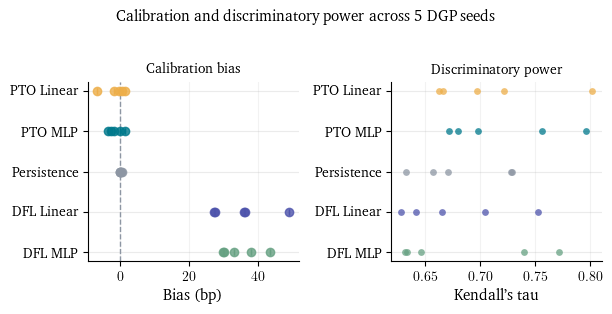

In [7]:
def _strip_plot(ax, df, value_col, models, title, xlabel, err_col=None, overlay_col=None, overlay_label=None):
    y = np.arange(len(models))
    for yi, model in zip(y, models):
        sub = df[df["model"] == model].dropna(subset=[value_col])
        if not sub.empty:
            vals = sub[value_col].to_numpy(dtype=float)
            yv = np.full(len(vals), float(yi))
            if err_col is not None:
                errs = 1.96 * sub[err_col].to_numpy(dtype=float)
                ax.errorbar(vals, yv, xerr=errs, fmt="o", ms=6, color=MODEL_COLOURS[model],
                            ecolor=MODEL_COLOURS[model], alpha=.8, capsize=2.5, lw=1.3, zorder=3)
            else:
                ax.scatter(vals, yv, s=24, color=MODEL_COLOURS[model], alpha=.75, zorder=3, linewidths=0)
        if overlay_col is not None:
            osub = df[df["model"] == model].dropna(subset=[overlay_col])
            if not osub.empty:
                ovals = osub[overlay_col].to_numpy(dtype=float)
                ax.scatter(ovals, np.full(len(ovals), yi + 0.24), s=26, facecolors="none",
                           edgecolors=MODEL_COLOURS[model], marker="D", linewidths=1.3, alpha=.85, zorder=3)
    ax.set_yticks(y, [DISPLAY_NAMES[m] for m in models]); ax.invert_yaxis()
    ax.set_title(title, fontsize=10); ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=.16); ax.set_axisbelow(True)


fig, axes = plt.subplots(1, 2, figsize=(6.22, 3.0))
_strip_plot(axes[0], calibration_by_seed, "bias_bp_realised", PD_MODELS,
            "Calibration bias", "Bias (bp)", err_col="hac_se_realised")
axes[0].axvline(0, color=MINOU_COLOURS["grey"], ls="--", lw=1, zorder=1)
_strip_plot(axes[1], discrimination_by_seed, "tau", PD_MODELS,
            "Discriminatory power", "Kendall\'s tau")
fig.suptitle(f"Calibration and discriminatory power across {n_ok} DGP seeds", fontsize=11, y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "audit_calibration_discrimination.pdf", dpi=300, bbox_inches="tight")
display(fig); plt.close(fig)

## Stability figure

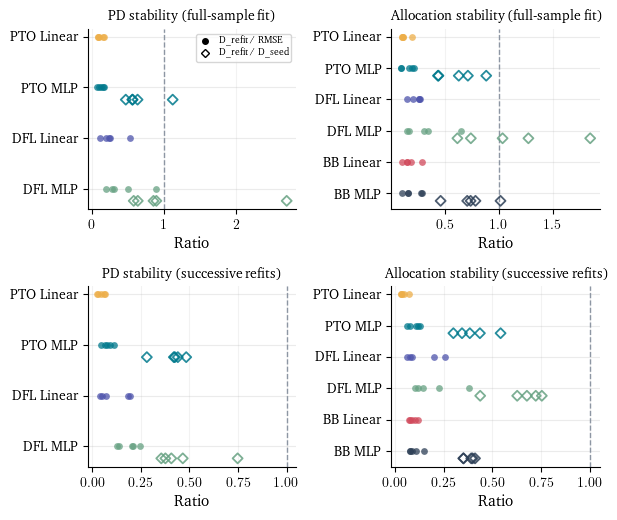

In [8]:
pd_models_stab = [m for m, _, _ in COMBOS if m in PD_MODELS and m in stability_by_seed["model"].unique()]
alpha_models_stab = [m for m, _, _ in COMBOS if m in stability_by_seed["model"].unique()]

fig, axes = plt.subplots(2, 2, figsize=(6.22, 5.3))
_strip_plot(axes[0, 0], stability_by_seed, "D_PD_full_over_RMSE_realised", pd_models_stab,
            "PD stability (full-sample fit)", "Ratio",
            overlay_col="D_PD_full_over_D_seed", overlay_label="vs training-seed dispersion")
_strip_plot(axes[0, 1], stability_by_seed, "D_alpha_full_over_RMSE", alpha_models_stab,
            "Allocation stability (full-sample fit)", "Ratio",
            overlay_col="D_alpha_full_over_D_seed", overlay_label="vs training-seed dispersion")
_strip_plot(axes[1, 0], stability_by_seed, "D_PD_successive_over_RMSE_realised", pd_models_stab,
            "PD stability (successive refits)", "Ratio",
            overlay_col="D_PD_successive_over_D_seed", overlay_label="vs training-seed dispersion")
_strip_plot(axes[1, 1], stability_by_seed, "D_alpha_successive_over_RMSE", alpha_models_stab,
            "Allocation stability (successive refits)", "Ratio",
            overlay_col="D_alpha_successive_over_D_seed", overlay_label="vs training-seed dispersion")
legend_proxies = [plt.Line2D([], [], marker="o", linestyle="", color="black",
                              label="D_refit / RMSE"),
                   plt.Line2D([], [], marker="D", linestyle="", markerfacecolor="none",
                              markeredgecolor="black",
                              label="D_refit / D_seed")]
axes[0, 0].legend(handles=legend_proxies, fontsize=7, loc="upper right", frameon=True,
                   borderpad=0.35, labelspacing=0.25, handlelength=1.2)
for ax in axes.flat:
    ax.axvline(1, color=MINOU_COLOURS["grey"], ls="--", lw=1, zorder=1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "simulation_audit_stability.pdf", dpi=300, bbox_inches="tight")
display(fig); 
plt.close(fig)

## DFL MLP Stability


In [9]:
dfl_mlp_alpha_rows, dfl_mlp_pd_rows = [], []
for seed in AUDIT_SEEDS:
    ref = load_reference_predictions("dfl", "mlp", seed=seed)
    if ref is None:
        continue

    d_alpha_full, _ = dispersion_full_sample(ref, "alpha_hat")
    d_alpha_succ, _ = dispersion_successive(ref, "alpha_hat")
    d_seed_alpha = dispersion_seed(ref, "alpha_hat", configs.MLP_ENSEMBLE_SEEDS)
    dfl_mlp_alpha_rows.append({
        "DGP seed": seed, "D_alpha_full": d_alpha_full, "D_alpha_successive": d_alpha_succ,
        "D_seed_alpha": d_seed_alpha,
        "D_alpha_full_over_D_seed": d_alpha_full / d_seed_alpha if d_seed_alpha else np.nan,
        "D_alpha_successive_over_D_seed": d_alpha_succ / d_seed_alpha if d_seed_alpha else np.nan,
    })

    d_pd_full, _ = dispersion_full_sample(ref, "pd_q_hat")
    d_pd_succ, _ = dispersion_successive(ref, "pd_q_hat")
    d_seed_pd = dispersion_seed(ref, "pd_q_hat", configs.MLP_ENSEMBLE_SEEDS)
    dfl_mlp_pd_rows.append({
        "DGP seed": seed, "D_PD_full": d_pd_full, "D_PD_successive": d_pd_succ,
        "D_seed_PD": d_seed_pd,
        "D_PD_full_over_D_seed": d_pd_full / d_seed_pd if d_seed_pd else np.nan,
        "D_PD_successive_over_D_seed": d_pd_succ / d_seed_pd if d_seed_pd else np.nan,
    })

dfl_mlp_alpha_table = pd.DataFrame(dfl_mlp_alpha_rows).sort_values("D_alpha_full_over_D_seed", ascending=False).reset_index(drop=True)
dfl_mlp_pd_table = pd.DataFrame(dfl_mlp_pd_rows).sort_values("D_PD_full_over_D_seed", ascending=False).reset_index(drop=True)

print("DFL MLP allocation-stability components:")
display(dfl_mlp_alpha_table.style.format({"D_alpha_full": "{:.6f}", "D_alpha_successive": "{:.6f}",
                                           "D_seed_alpha": "{:.6f}",
                                           "D_alpha_full_over_D_seed": "{:.3f}",
                                           "D_alpha_successive_over_D_seed": "{:.3f}"}))

print("DFL MLP predicted-PD stability components:")
display(dfl_mlp_pd_table.style.format({"D_PD_full": "{:.6f}", "D_PD_successive": "{:.6f}",
                                        "D_seed_PD": "{:.6f}",
                                        "D_PD_successive_over_D_seed": "{:.3f}"}))

DFL MLP allocation-stability components:


,DGP seed,D_alpha_full,D_alpha_successive,D_seed_alpha,D_alpha_full_over_D_seed,D_alpha_successive_over_D_seed
0,46,0.031468,0.012310,0.017061,1.844,0.722
1,45,0.038135,0.022544,0.029955,1.273,0.753
2,43,0.031170,0.020384,0.030141,1.034,0.676
3,42,0.016745,0.014166,0.022608,0.741,0.627
4,44,0.013467,0.009553,0.021847,0.616,0.437


DFL MLP predicted-PD stability components:


,DGP seed,D_PD_full,D_PD_successive,D_seed_PD,D_PD_full_over_D_seed,D_PD_successive_over_D_seed
0,46,0.003060,0.000848,0.001133,2.699661,0.748
1,44,0.001183,0.000539,0.001322,0.894745,0.408
2,45,0.002209,0.000920,0.002585,0.854517,0.356
3,42,0.000874,0.000640,0.001371,0.637345,0.467
4,43,0.001874,0.001217,0.003227,0.580537,0.377


## DFL MLP reference-point diagnostics

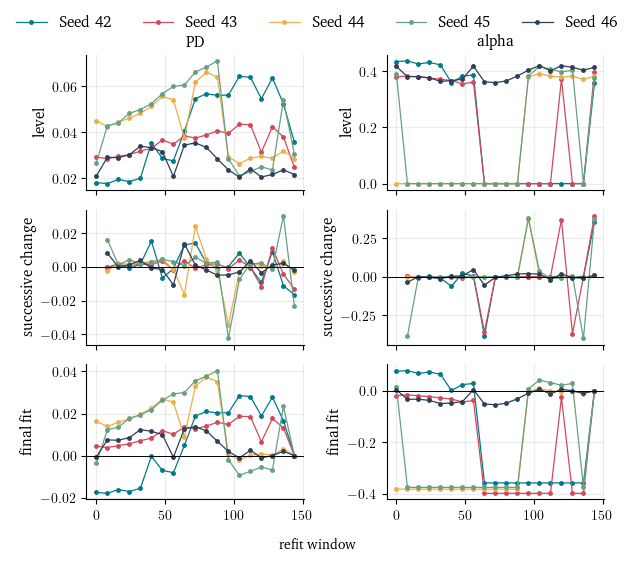

In [10]:
diag_seed = 45
diag_path = paths.stability_mlp_csv("dfl", diag_seed, BASELINE_LAMBDA, BASELINE_T, BASELINE_RHO, SPLIT_NAME)
diag_stab = pd.read_csv(diag_path, parse_dates=["test_date"]); diag_seeds = list(configs.MLP_ENSEMBLE_SEEDS)
diag_refs = sorted({int(c[3:c.index("_")]) for c in diag_stab.columns if c.startswith("ref") and "_alpha_hat_seed" in c})

def diag_v(metric, ref, seed): 
    return diag_stab[f"ref{ref}_{metric}_seed{seed}"].to_numpy()

diag_seed_mean = {metric: {r: np.mean([diag_v(metric, r, s) for s in diag_seeds], axis=0) for r in diag_refs} for metric in ["pd_q_hat", "alpha_hat"]}
diag_full_rms_alpha = {r: float(np.sqrt(np.mean((v - v[-1]) ** 2))) for r, v in diag_seed_mean["alpha_hat"].items()}
diag_succ_rms_alpha = {r: float(np.sqrt(np.mean(np.diff(v) ** 2))) for r, v in diag_seed_mean["alpha_hat"].items()}
diag_full_rms_pd = {r: float(np.sqrt(np.mean((v - v[-1]) ** 2))) for r, v in diag_seed_mean["pd_q_hat"].items()}
diag_succ_rms_pd = {r: float(np.sqrt(np.mean(np.diff(v) ** 2))) for r, v in diag_seed_mean["pd_q_hat"].items()}

common_refs = diag_refs

def _common_score(ref):
    values = [diag_full_rms_alpha.get(ref, np.nan), diag_succ_rms_alpha.get(ref, np.nan),
                diag_full_rms_pd.get(ref, np.nan), diag_succ_rms_pd.get(ref, np.nan)]
    return np.nanmean(values)
common_ref = max(common_refs, key=_common_score)
fig, axes = plt.subplots(3, 2, figsize=(6.22, 6.0), sharex=True, squeeze=False)
for col, (metric, ylabel, title) in enumerate([("pd_q_hat", "level", "PD"), ("alpha_hat", "level", "alpha")]):
    for seed_idx, s in enumerate(diag_seeds):
        values = diag_v(metric, common_ref, s)
        seed_color = [MINOU_COLOURS["teal"], MINOU_COLOURS["coral"], MINOU_COLOURS["gold"], MINOU_COLOURS["sage"], MINOU_COLOURS["navy"]][seed_idx % 5]
        axes[0, col].plot(diag_stab.refit_step, values, marker="o", ms=2.5, lw=.9, color=seed_color, label=f"Seed {s}")
        axes[1, col].plot(diag_stab.refit_step.iloc[1:], np.diff(values), marker="o", ms=2.5, lw=.9, color=seed_color)
        axes[2, col].plot(diag_stab.refit_step, values - values[-1], marker="o", ms=2.5, lw=.9, color=seed_color)
    axes[0, col].set_title(f"{title}")
    axes[0, col].set_ylabel(ylabel)
    axes[1, col].set_ylabel("successive change")
    axes[2, col].set_ylabel("final fit")
    axes[1, col].axhline(0, color="black", lw=.7); axes[2, col].axhline(0, color="black", lw=.7)
    for row in range(3): axes[row, col].grid(alpha=.25)
fig.supxlabel("refit window", y=0.065, fontsize=10)
legend_handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=min(len(legend_labels), 5), frameon=False, fontsize=11)
fig.tight_layout(rect=(0, 0.04, 1, 0.95))
fig.savefig(FIGURES_DIR/ f"DFL_MLP_unstable_reference_point.pdf", dpi=200, bbox_inches="tight")
plt.show()

## DFL MLP ensemble reference-point diagnostics for seed 45


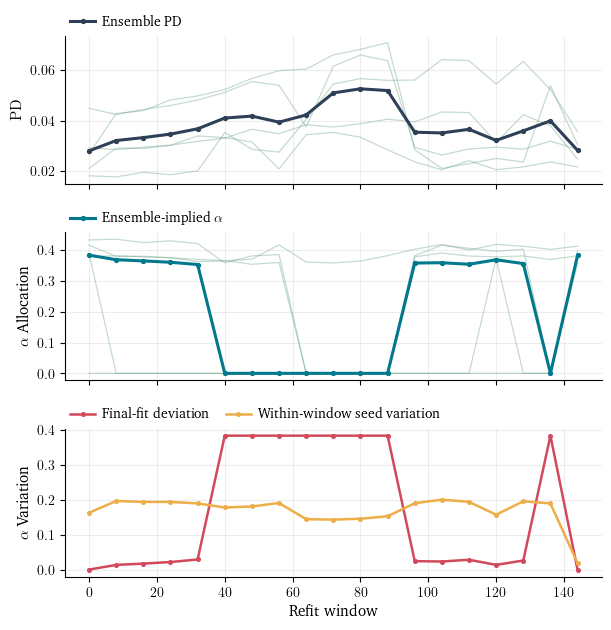

In [11]:
alpha45_ref = common_ref

pd45 = diag_stab[f"ref{alpha45_ref}_pd_q_hat_mean"].to_numpy(dtype=float)
pd45_members = np.column_stack([diag_stab[f"ref{alpha45_ref}_pd_q_hat_seed{s}"].to_numpy(dtype=float) for s in diag_seeds])
alpha45 = diag_stab[f"ref{alpha45_ref}_alpha_hat_mean"].to_numpy(dtype=float)
alpha45_members = np.column_stack([diag_stab[f"ref{alpha45_ref}_alpha_hat_seed{s}"].to_numpy(dtype=float) for s in diag_seeds])
alpha45_drefit = np.abs(alpha45 - alpha45[-1])
alpha45_dseed_w = alpha45_members.std(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(6.22, 6.4), sharex=True, squeeze=False)
legend_kwargs = dict(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, borderaxespad=0, handlelength=1.8,handletextpad=0.5,)

# Ensemble PD
ax = axes[0, 0]
for j, s in enumerate(diag_seeds):
    ax.plot(diag_stab.refit_step, pd45_members[:, j], color=MINOU_COLOURS["sage"], alpha=.38, lw=.9)
ax.plot(diag_stab.refit_step, pd45, color=MINOU_COLOURS["navy"], lw=2.2, marker="o", ms=2.8, label="Ensemble PD")
ax.set_ylabel(r"$\mathrm{PD}$")
ax.legend(**legend_kwargs)

# Ensemble-implied allocation
ax = axes[1, 0]
for j, s in enumerate(diag_seeds):
    ax.plot(diag_stab.refit_step, alpha45_members[:, j], color=MINOU_COLOURS["sage"], alpha=.38, lw=.9)
ax.plot(diag_stab.refit_step, alpha45, color=MINOU_COLOURS["teal"], lw=2.2, marker="o", ms=2.8, label=r"Ensemble-implied $\alpha$")
ax.set_ylabel(r"$\alpha$ Allocation")
ax.legend(**legend_kwargs)

# Allocation variation
ax = axes[2, 0]
ax.plot(diag_stab.refit_step, alpha45_drefit,color=MINOU_COLOURS["coral"],lw=1.8,marker="o",ms=2.6, label="Final-fit deviation",)
ax.plot(diag_stab.refit_step, alpha45_dseed_w, color=MINOU_COLOURS["gold"],lw=1.8,marker="o",ms=2.6,label="Within-window seed variation",)
ax.set_ylabel(r"$\alpha$ Variation")
ax.set_xlabel("Refit window")
ax.legend(**legend_kwargs, ncol=2, columnspacing=1.2,)

for ax in axes[:, 0]:
    ax.grid(alpha=.22)
    ax.set_axisbelow(True)

fig.tight_layout(h_pad=1.3)

fig.savefig(FIGURES_DIR / "DFL_MLP_seed45_ref_point.pdf",dpi=200,bbox_inches="tight",)

plt.show()